In [1]:
from console_prometheus import *

In [67]:
RAW_COOKIE = """
Cookie
	openshift-session-token=sha256~XDV5RKGwNh0FnUu3yFTWtQgOn1kFvKjoF1p_H8L_kuc; gu_analytics=true; gu_remarketing=true; gu_hotjar=true; gu_baidu_analytics=true; gu_consent_set=true; csrf-token=RE+8LF8AMSetqb4bxNPC80XbV27yp8KfzUZHbMPSnow5YpCNpOpWd6NWLPRkuLlh9cAzND05AFxH6sN1Sd0zsg==; 1e2670d92730b515ce3a1bb65da45062=8a25be24514dc15582b8a59b8d92d7ee
"""

HEADERS = {
    "Accept": "application/json",
    "Cookie": clean_cookie(RAW_COOKIE),
}

namespace = "pgr24james" 


In [68]:
CPU_QUERY = """
sum by (pod, container) (
  irate(container_cpu_usage_seconds_total{
    namespace="pgr24james",
    pod=~"trino.*",
    container=~"trino-worker|trino-coord"
  }[2m])
)
"""

data = prom_query(query, HEADERS)
print(f"Returned {data['data']['result']} series")

Returned [{'metric': {'container': 'trino-coord', 'pod': 'trino-coord-pod-lakehouse-c'}, 'value': [1778076736.213, '0.05707669999999893']}, {'metric': {'container': 'trino-worker', 'pod': 'trino-worker-lakehouse-c-2-0'}, 'value': [1778076736.213, '0.06419429400386775']}, {'metric': {'container': 'trino-worker', 'pod': 'trino-worker-lakehouse-c-1-0'}, 'value': [1778076736.213, '0.042009097322788055']}, {'metric': {'container': 'trino-worker', 'pod': 'trino-worker-lakehouse-c-3-0'}, 'value': [1778076736.213, '0.05069684202945544']}] series


In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from IPython.display import clear_output
from datetime import datetime


def fetch_pod_metric(query, headers):
    """
    Returns:
        timestamp: pd.Timestamp
        pod_values: dict[pod_name] -> float
    """
    data = prom_query(query, headers)

    results = data["data"]["result"]
    ts = pd.Timestamp.utcnow()

    pod_values = {}
    for r in results:
        pod = r["metric"].get("pod", "unknown")
        value = float(r["value"][1])
        pod_values[pod] = value

    return ts, pod_values

def live_dispersion_plot(
    query,
    headers,
    poll_seconds=5,
    max_points=60,
    iterations=None,
    title="Trino pod CPU usage dispersion over time",
    ylabel="CPU cores used"
):
    """
    Live-updating plot of pod-level performance dispersion.

    Parameters
    ----------
    query : str
        PromQL instant query returning one series per pod.
    headers : dict
        Headers passed to prom_query.
    poll_seconds : int
        Polling interval.
    max_points : int
        Number of historical points to keep.
    iterations : int | None
        If None, run forever. Otherwise stop after this many iterations.
    """
    history = []
    count = 0

    while True:
        ts, pod_values = fetch_pod_metric(query, headers)
        history.append((ts, pod_values))

        if len(history) > max_points:
            history = history[-max_points:]

        # Build a rectangular dataframe: rows=time, cols=pod
        all_pods = sorted({p for _, vals in history for p in vals.keys()})
        rows = []
        idx = []

        for t, vals in history:
            row = {pod: vals.get(pod, np.nan) for pod in all_pods}
            rows.append(row)
            idx.append(t)

        df = pd.DataFrame(rows, index=idx).sort_index()

        # Summary statistics across pods at each timestamp
        median = df.median(axis=1, skipna=True)
        q25 = df.quantile(0.25, axis=1, interpolation="linear")
        q75 = df.quantile(0.75, axis=1, interpolation="linear")
        min_ = df.min(axis=1, skipna=True)
        max_ = df.max(axis=1, skipna=True)

        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(12, 6))

        # Individual pod lines
        for pod in df.columns:
            ax.plot(df.index, df[pod], linewidth=1, alpha=0.7, label=pod)

        # Dispersion bands
        ax.fill_between(df.index, min_.values, max_.values, alpha=0.12, label="Min–Max range")
        ax.fill_between(df.index, q25.values, q75.values, alpha=0.25, label="IQR (25th–75th pct)")
        ax.plot(df.index, median.values, linewidth=2.5, label="Median")

        ax.set_title(title)
        ax.set_xlabel("Time")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0.)
        plt.tight_layout()
        plt.show()

        # Optional textual summary
        latest = df.iloc[-1].dropna()
        if len(latest) > 0:
            print("Latest pod values:")
            display(latest.sort_values(ascending=False).to_frame("value"))

            print("\nLatest summary:")
            print(f"min    = {latest.min():.4f}")
            print(f"q25    = {latest.quantile(0.25):.4f}")
            print(f"median = {latest.median():.4f}")
            print(f"q75    = {latest.quantile(0.75):.4f}")
            print(f"max    = {latest.max():.4f}")
            print(f"mean   = {latest.mean():.4f}")
            print(f"std    = {latest.std():.4f}")

        count += 1
        if iterations is not None and count >= iterations:
            break

        time.sleep(poll_seconds)

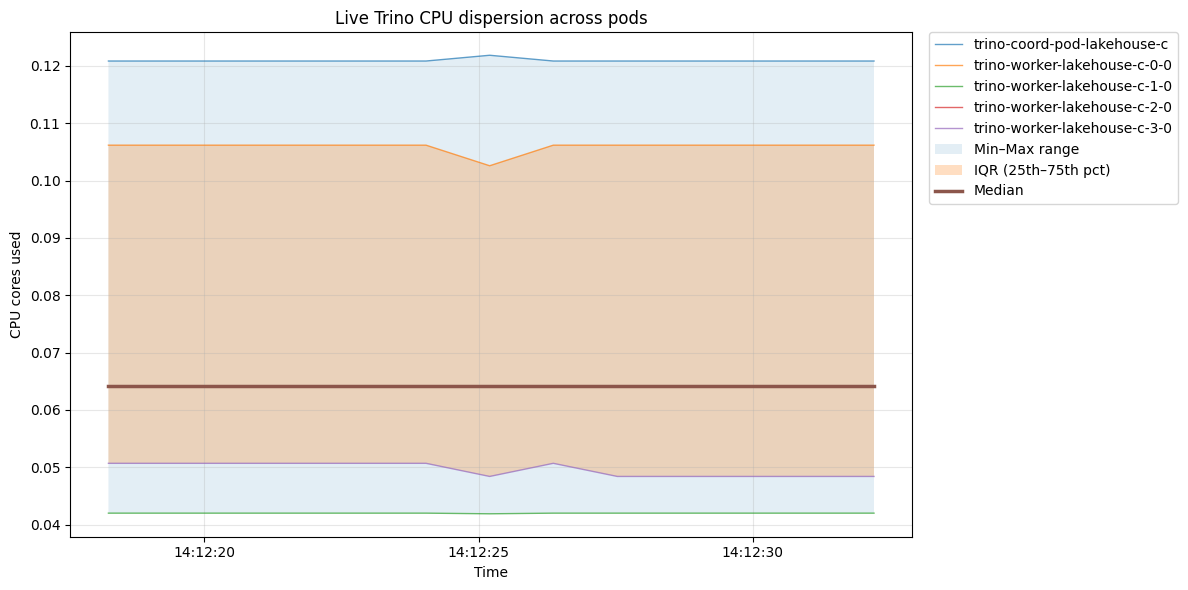

Latest pod values:


,value
trino-coord-pod-lakehouse-c,0.120831
trino-worker-lakehouse-c-0-0,0.106160
trino-worker-lakehouse-c-2-0,0.064194
trino-worker-lakehouse-c-3-0,0.048408
trino-worker-lakehouse-c-1-0,0.042009



Latest summary:
min    = 0.0420
q25    = 0.0484
median = 0.0642
q75    = 0.1062
max    = 0.1208
mean   = 0.0763
std    = 0.0353


KeyboardInterrupt: 

In [70]:
live_dispersion_plot(
    query=CPU_QUERY,
    headers=HEADERS,
    poll_seconds=1,
    max_points=60,
    iterations=None,   # or None to keep running
    title="Live Trino CPU dispersion across pods",
    ylabel="CPU cores used"
)

In [66]:
import re
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import clear_output, display


# ---------------------------------------------------------------------
# Endpoint config
# ---------------------------------------------------------------------

METRICS_URL = "http://trino-service-lakehouse-c.pgr24james.svc.cluster.local:9100/metrics"


# ---------------------------------------------------------------------
# Raw endpoint scraping
# ---------------------------------------------------------------------

def scrape_metrics_text(url=METRICS_URL, timeout=3):
    """
    Pull raw Prometheus text from a metrics endpoint.
    """
    resp = requests.get(url, timeout=timeout)
    resp.raise_for_status()
    return resp.text


def parse_node_cpu_seconds(metrics_text):
    """
    Parse node_cpu_seconds_total into:

        node_cpu_seconds[cpu][mode] = value

    Example metric line:
        node_cpu_seconds_total{cpu="0",mode="idle"} 12345.67
    """
    pattern = re.compile(
        r'^node_cpu_seconds_total\{([^}]*)\}\s+([0-9.eE+-]+)',
        re.MULTILINE,
    )

    out = {}

    for match in pattern.finditer(metrics_text):
        labels_raw = match.group(1)
        value = float(match.group(2))

        labels = {}
        for part in labels_raw.split(","):
            if "=" not in part:
                continue
            k, v = part.split("=", 1)
            labels[k.strip()] = v.strip().strip('"')

        cpu = labels.get("cpu")
        mode = labels.get("mode")

        if cpu is None or mode is None:
            continue

        out.setdefault(cpu, {})[mode] = value

    return out


def snapshot_node_cpu(url=METRICS_URL):
    """
    Return one raw node CPU snapshot.

    Returns
    -------
    timestamp : pd.Timestamp
    cpu_seconds : dict
        cpu -> mode -> cumulative seconds
    """
    text = scrape_metrics_text(url)
    return pd.Timestamp.utcnow(), parse_node_cpu_seconds(text)


# ---------------------------------------------------------------------
# CPU utilisation from consecutive raw counter snapshots
# ---------------------------------------------------------------------

def compute_cpu_utilisation(prev_cpu, curr_cpu):
    """
    Compute per-core and aggregate CPU utilisation between two snapshots.

    Returns
    -------
    per_cpu_util : dict[str, float]
        cpu id -> utilisation fraction between 0 and 1
    aggregate_util : float
        mean utilisation across CPUs
    """
    per_cpu_util = {}

    for cpu, curr_modes in curr_cpu.items():
        prev_modes = prev_cpu.get(cpu)
        if not prev_modes:
            continue

        modes = set(curr_modes) & set(prev_modes)
        if not modes:
            continue

        deltas = {
            mode: curr_modes[mode] - prev_modes[mode]
            for mode in modes
        }

        total_delta = sum(v for v in deltas.values() if v >= 0)
        idle_delta = deltas.get("idle", 0.0) + deltas.get("iowait", 0.0)

        if total_delta <= 0:
            continue

        util = 1.0 - (idle_delta / total_delta)
        per_cpu_util[cpu] = max(0.0, min(1.0, util))

    if per_cpu_util:
        aggregate_util = float(np.mean(list(per_cpu_util.values())))
    else:
        aggregate_util = np.nan

    return per_cpu_util, aggregate_util


def fetch_node_cpu_utilisation(url=METRICS_URL, interval_seconds=1.0):
    """
    Pull two snapshots and compute near-current node CPU utilisation.

    This avoids Prometheus rate windows and computes the delta directly.
    """
    _, prev_cpu = snapshot_node_cpu(url)
    time.sleep(interval_seconds)
    ts, curr_cpu = snapshot_node_cpu(url)

    per_cpu_util, aggregate_util = compute_cpu_utilisation(prev_cpu, curr_cpu)

    values = {
        f"cpu_{cpu}": util * 100.0
        for cpu, util in per_cpu_util.items()
    }

    values["aggregate"] = aggregate_util * 100.0

    return ts, values

def live_endpoint_cpu_dispersion_plot(
    url=METRICS_URL,
    sample_interval_seconds=1.0,
    poll_seconds=1.0,
    max_points=60,
    iterations=None,
    title="Live node CPU utilisation dispersion",
    ylabel="CPU utilisation (%)",
):
    """
    Live-updating plot of CPU utilisation dispersion from a raw metrics endpoint.

    This does not use Prometheus rate().
    It computes utilisation from two consecutive raw counter snapshots.
    """
    history = []
    count = 0

    while True:
        ts, cpu_values = fetch_node_cpu_utilisation(
            url=url,
            interval_seconds=sample_interval_seconds,
        )

        history.append((ts, cpu_values))

        if len(history) > max_points:
            history = history[-max_points:]

        all_series = sorted({k for _, vals in history for k in vals.keys()})

        rows = []
        idx = []

        for t, vals in history:
            row = {name: vals.get(name, np.nan) for name in all_series}
            rows.append(row)
            idx.append(t)

        df = pd.DataFrame(rows, index=idx).sort_index()

        # Do not include aggregate in dispersion band calculation
        core_cols = [c for c in df.columns if c != "aggregate"]
        core_df = df[core_cols]

        median = core_df.median(axis=1, skipna=True)
        q25 = core_df.quantile(0.25, axis=1)
        q75 = core_df.quantile(0.75, axis=1)
        min_ = core_df.min(axis=1, skipna=True)
        max_ = core_df.max(axis=1, skipna=True)

        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(12, 6))

        # Individual CPU core lines
        for col in core_cols:
            ax.plot(df.index, df[col], linewidth=0.8, alpha=0.45)

        # Aggregate line
        if "aggregate" in df.columns:
            ax.plot(
                df.index,
                df["aggregate"],
                linewidth=2.5,
                label="Aggregate mean CPU",
            )

        # Dispersion bands
        ax.fill_between(
            df.index,
            min_.values,
            max_.values,
            alpha=0.12,
            label="Core min–max range",
        )
        ax.fill_between(
            df.index,
            q25.values,
            q75.values,
            alpha=0.25,
            label="Core IQR",
        )
        ax.plot(
            df.index,
            median.values,
            linewidth=2.0,
            label="Core median",
        )

        ax.set_title(title)
        ax.set_xlabel("Time")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0.)
        plt.tight_layout()
        plt.show()

        latest = df.iloc[-1].dropna()

        if len(latest) > 0:
            print("Latest values:")
            display(latest.sort_values(ascending=False).to_frame("value"))

            core_latest = latest.drop(labels=["aggregate"], errors="ignore")

            if len(core_latest) > 0:
                print("\nLatest core summary:")
                print(f"min    = {core_latest.min():.2f}%")
                print(f"q25    = {core_latest.quantile(0.25):.2f}%")
                print(f"median = {core_latest.median():.2f}%")
                print(f"q75    = {core_latest.quantile(0.75):.2f}%")
                print(f"max    = {core_latest.max():.2f}%")
                print(f"mean   = {core_latest.mean():.2f}%")
                print(f"std    = {core_latest.std():.2f}%")

        count += 1

        if iterations is not None and count >= iterations:
            break

        time.sleep(poll_seconds)

live_endpoint_cpu_dispersion_plot(
url="http://trino-service-lakehouse-c.pgr24james.svc.cluster.local:9100/metrics",
sample_interval_seconds=1.0,
poll_seconds=1.0,
max_points=60,
iterations=None,
)

ConnectTimeout: HTTPConnectionPool(host='trino-service-lakehouse-c.pgr24james.svc.cluster.local', port=9100): Max retries exceeded with url: /metrics (Caused by ConnectTimeoutError(<urllib3.connection.HTTPConnection object at 0x7f6478947a30>, 'Connection to trino-service-lakehouse-c.pgr24james.svc.cluster.local timed out. (connect timeout=3)'))